# Why is LIRS so bad at the cluster008 sample?

Because keys are touched at very long time distances.

This trashes the LIRS stack, pushing junk keys to it (the stack grows and remembers all). When a new "good" key comes, it is very hard for it to evict a LIR "bad" key because a second hit is required. But the LIRS cache HIR queue is too small (<= 500 elements) when we need on average >1200 steps for a second hit.

On the other hand: LRU doesn't think that any key has a privilege, so old keys are evicted fast.

Here are graphics illustrating the problem:

In [1]:
import statistics
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "../cluster008-parsed.txt"

In [3]:
keys = []
with open(path, 'r', encoding='utf-8') as file:
    type, size = file.readline().strip().split()
    size = int(size)

    for i in range(size):
        key_str = file.readline().strip()
        keys.append(int(key_str))

print(len(keys))


1000000


In [4]:
keys_frequencies = {}
for key in keys:
    if key not in keys_frequencies:
        keys_frequencies[key] = 0
    keys_frequencies[key] += 1


def print_stat(values):
    max_val = max(values)
    min_val = min(values)
    print(f"Max: {max_val}")
    print(f"Min: {min_val}")

    avg_val = sum(values) / len(values)
    print(f"AVG: {avg_val:.2f}")

    median_val = statistics.median(values)
    print(f"Median: {median_val}")


print_stat(values=keys_frequencies.values())

Max: 102
Min: 1
AVG: 8.84
Median: 6.0


In [5]:
def print_by_buckets(keys, num_buckets = None, title = None):

    plt.figure(figsize=(14, 6))
    if num_buckets is not None:
        max_value = max(keys);
        min_value = min(keys);
        bucket_step = (max_value - min_value + 1) // num_buckets
        buckets = list(range(min_value, max_value + bucket_step, bucket_step))
        counts, bins, patches = plt.hist(keys, bins=buckets, edgecolor='black', color='skyblue', alpha=0.7)
        plt.xticks(buckets)
    else:
        counts, bins, patches = plt.hist(keys, edgecolor='black', color='skyblue', alpha=0.7)

    if title is not None: 
        plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()


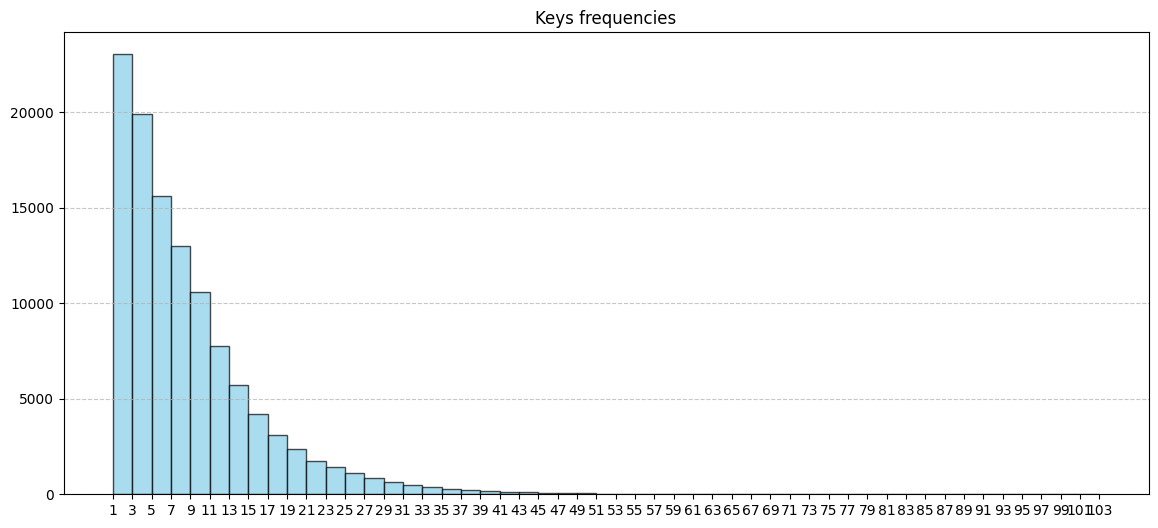

In [6]:
print_by_buckets(keys=list(keys_frequencies.values()), num_buckets=40, title="Keys frequencies")

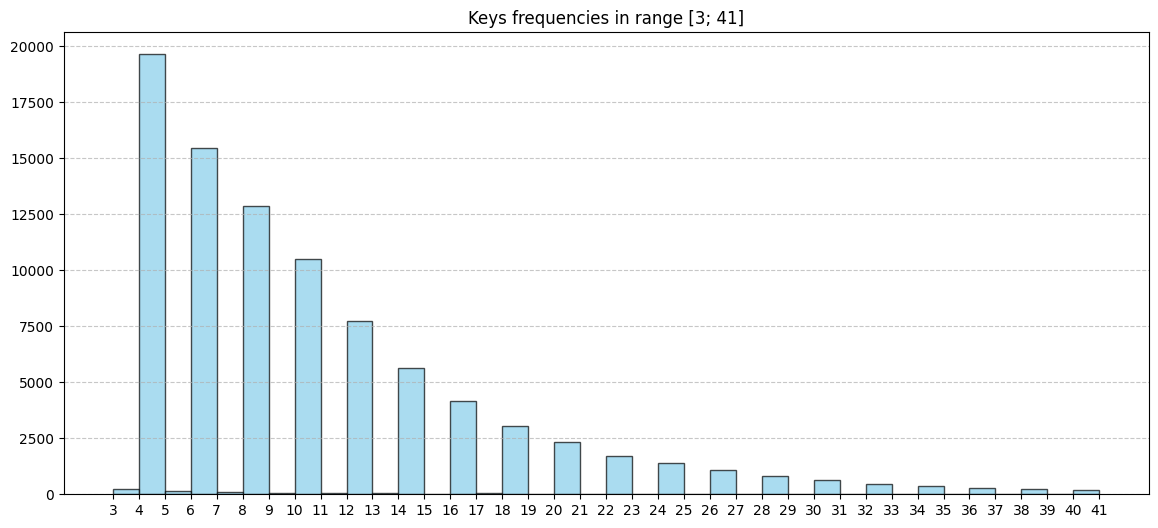

In [7]:
print_by_buckets(keys=[f for f in (list(keys_frequencies.values())) if 3 <= f <= 41],
                            num_buckets=20, title="Keys frequencies in range [3; 41]")

In [8]:
def get_key_inter_reference_stats(keys):
    keys_last_used_times = {}
    keys_timings = {}
    
    current_time = 0
    for key in keys:
        if key not in keys_last_used_times:
            keys_last_used_times[key] = 0
        else:
            delta = current_time - keys_last_used_times[key]
            if key not in keys_timings:
                keys_timings[key] = []
            keys_timings[key].append(delta)
    
        keys_last_used_times[key] = current_time;
        current_time += 1

    return keys_timings

In [9]:
hot_keys = [k for k in keys if 3 <= keys_frequencies[k] <= 41]
hot_keys_timings = get_key_inter_reference_stats(keys=hot_keys)
hot_keys_timings_only = []
for k, v in hot_keys_timings.items():
    hot_keys_timings_only.extend(v)


keys_timings = get_key_inter_reference_stats(keys=keys)
keys_timings_only = []
for k, v in keys_timings.items():
    keys_timings_only.extend(v)

# Inter-reference time array statistics:

In [10]:
print_stat(values=hot_keys_timings_only)

Max: 919786
Min: 1
AVG: 64084.59
Median: 1229.0


In [11]:
print_stat(values=keys_timings_only)

Max: 994233
Min: 1
AVG: 65846.96
Median: 1266.0


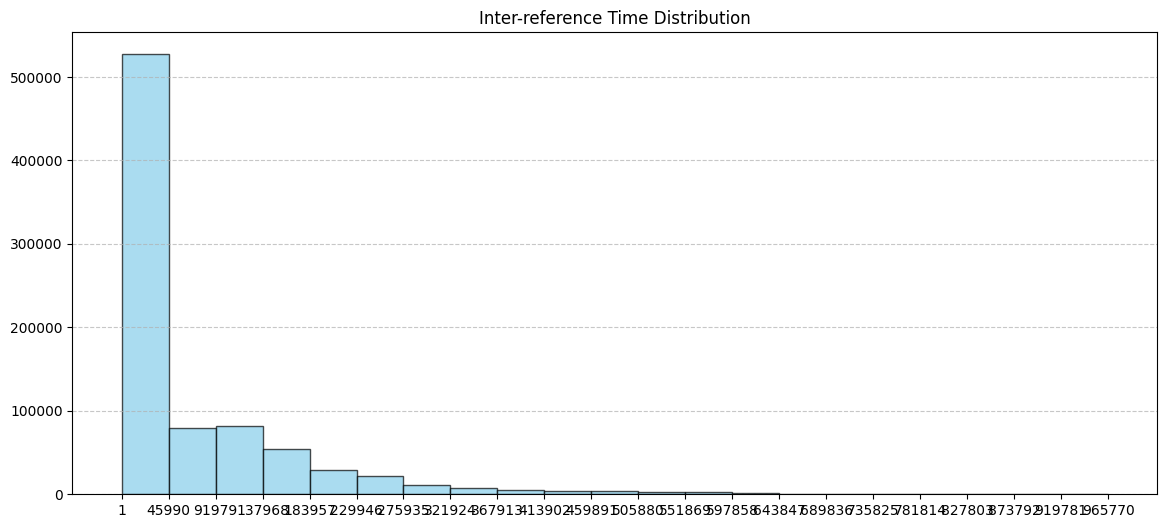

In [12]:
print_by_buckets(keys=hot_keys_timings_only, num_buckets=20, title="Inter-reference Time Distribution")

Bad cases: 371152


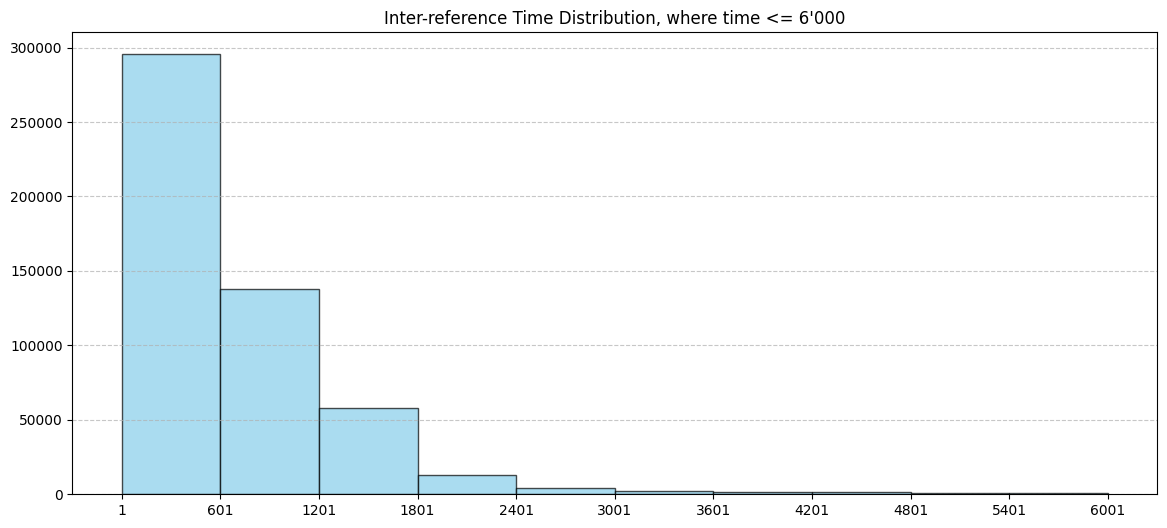

In [13]:
print(f"Bad cases: {len([t for t in keys_timings_only if t > 6_000])}")
print_by_buckets(keys=[t for t in keys_timings_only if t <= 6_000], num_buckets=10, title="Inter-reference Time Distribution, where time <= 6'000")

In [14]:
bad_cases  = [t for t in keys_timings_only if t > 4500]
good_cases = [t for t in keys_timings_only if t <= 4500]

print(f"Bad cases: {len(bad_cases)}")
print(f"Good cases: {len(good_cases)}")
print(f"{len(good_cases) / (len(good_cases) + len(bad_cases)):.4f}")

Bad cases: 373850
Good cases: 513002
0.5785
